# Leafflication

This projects is an introduction to computer vision.  
It includes image data augmentation, transformation and classification.  

### Imports

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np

### Data distribution visualization

View image distributions on a pie chart.  

In [ ]:
IMAGES_DIRECTORY_PATH = './images'

def plot_files_distribution(directory_path):
    # Get the list of subdirectories
    subdirs = [d for d in os.listdir(directory_path) if os.path.isdir(os.path.join(directory_path, d))]

    # Count the number of images in each subdirectory
    file_counts = []
    for subdir in subdirs:
        subdir_path = os.path.join(directory_path, subdir)
        file_count = len([f for f in os.listdir(subdir_path) if os.path.isfile(os.path.join(subdir_path, f))])
        file_counts.append(file_count)

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    # Pie chart
    ax[0].pie(file_counts, labels=subdirs, autopct='%1.1f%%', startangle=140)
    ax[0].axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
    ax[0].set_title("Distribution of images (Percentage)")

    # Bar chart
    y_pos = np.arange(len(subdirs))
    bars = ax[1].bar(y_pos, file_counts, align='center', alpha=0.7)
    ax[1].set_xticks(y_pos)
    ax[1].set_xticklabels(subdirs, rotation=45, ha='right')
    ax[1].set_ylabel('Number of images')
    ax[1].set_title('Distribution of images (Count)')

    # Annotate the bars with their respective counts
    for bar in bars:
        height = bar.get_height()
        ax[1].text(bar.get_x() + bar.get_width()/2., height + 1,
                '%d' % int(height), ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

plot_files_distribution(IMAGES_DIRECTORY_PATH)

### Data augmentation
Augment data by flipping, blurring

In [14]:
%matplotlib inline

from pathlib import Path
import torch
import matplotlib.pyplot as plt
plt.rcParams["savefig.bbox"] = 'tight'

from torchvision.transforms import v2
from torchvision.io import read_image

torch.manual_seed(1)

# If you're trying to run that on collab, you can download the assets and the
# helpers from https://github.com/pytorch/vision/tree/main/gallery/
# from helpers import plot
img = read_image('/mnt/nfs/homes/maabidal/Downloads/astronaut.jpg')
# print(f"{type(img) = }, {img.dtype = }, {img.shape = }")

In [15]:
transform = v2.RandomCrop(size=(224, 224))
out = transform(img)


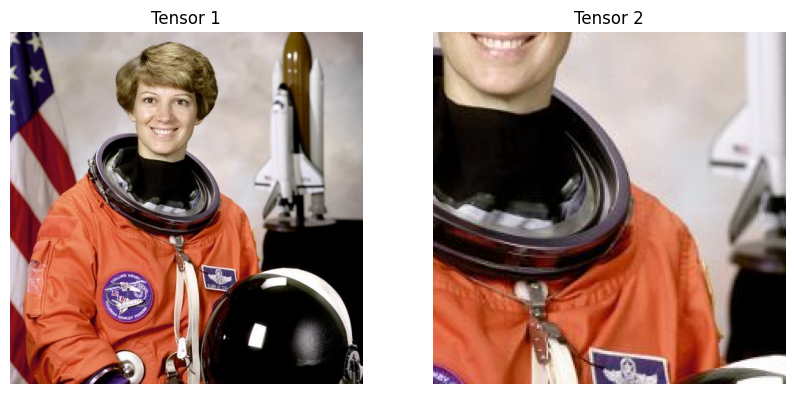

In [17]:
from PIL import Image

import numpy as np
# img = np.asarray(Image.open('/mnt/nfs/homes/maabidal/Downloads/astronaut.jpg'))
import matplotlib.pyplot as plt

def plot(tensor1, tensor2):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    
    # Convert tensor to numpy array and transpose if necessary
    # Assuming tensors are in the format CxHxW (channels, height, width)
    img1 = tensor1.numpy().transpose(1, 2, 0)
    img2 = tensor2.numpy().transpose(1, 2, 0)
    
    ax1.imshow(img1)
    ax1.set_title('Tensor 1')
    ax1.axis('off')
    
    ax2.imshow(img2)
    ax2.set_title('Tensor 2')
    ax2.axis('off')
    
    plt.show()

plot(img, out)